# GEPA quickstart — inside a persistent kernel

The smallest possible GEPA run, built to exercise **one** notebook ergonomic edge: the eval set, the trace history, the best-prompt-so-far, and the plotting state **all stay loaded in the same kernel namespace** across optimization rounds. A subprocess-based loop would reload them every iteration.

- **Library:** [`gepa`](https://github.com/gepa-ai/gepa) (Genetic-Pareto, ICLR 2026 Oral) cloned at `~/Documents/GitHub/gepa`
- **Model wiring:** AWS Bedrock via `litellm`, credentials loaded from `../../.env`
- **Budget:** `max_metric_calls=8` on 3 real AIME problems → bounded cost

> Reference framing: `~/Documents/GitHub/_docs/notebook/use-cases/01-gepa.md`.

## 1. Sanity-check the environment

Confirm the kernel sees `gepa` / `litellm` / `dotenv` before we start spending tokens.

In [2]:
import os
import sys

import gepa
import litellm

print("python  :", sys.executable)
print("cwd     :", os.getcwd())
print("gepa    :", os.path.dirname(gepa.__file__))
print("litellm :", litellm.__file__.split("/site-packages/")[-1].split("/")[0])

python  : /Users/mhuang/.cache/uv/builds-v0/.tmpsNZHpJ/bin/python
cwd     : /Users/mhuang/Documents/GitHub/abook
gepa    : /Users/mhuang/Documents/GitHub/abook/.venv/lib/python3.12/site-packages/gepa
litellm : litellm


## 2. Load Bedrock credentials from `.env`

`.env` is gitignored and lives at the repo root (`~/Documents/GitHub/abook/.env`). It holds `AWS_BEARER_TOKEN_BEDROCK` + `AWS_REGION` copied from the shell config (one-time). `litellm.completion` picks them up automatically once the env vars are set.

In [3]:
from pathlib import Path

from dotenv import load_dotenv

env_path = Path.cwd() / ".env"
load_dotenv(env_path)
print("env file       :", env_path)
print("exists         :", env_path.exists())
print(
    "BEDROCK token  :",
    "set" if os.environ.get("AWS_BEARER_TOKEN_BEDROCK") else "MISSING",
)
print("AWS_REGION     :", os.environ.get("AWS_REGION"))

env file       : /Users/mhuang/Documents/GitHub/abook/.env
exists         : True
BEDROCK token  : set
AWS_REGION     : us-east-1


## 3. Probe Bedrock with one cheap call

Before spending any optimization budget, verify the model wiring with a single completion. This is what every cell in every later notebook will route through.

In [4]:
litellm.drop_params = True  # gepa.lm sets this internally too; harmless here

TASK_LM = "bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0"
REFLECTION_LM = "bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0"

probe = litellm.completion(
    model=TASK_LM,
    messages=[{"role": "user", "content": "Reply with exactly one word: pong"}],
    max_tokens=8,
    temperature=0,
)
print("reply:", probe.choices[0].message.content.strip())
print("usage:", dict(probe.usage))

reply: pong
usage: {'completion_tokens': 5, 'prompt_tokens': 15, 'total_tokens': 20, 'completion_tokens_details': CompletionTokensDetailsWra
pper(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=0, rejected_prediction_tokens=None, text_tokens=5, ima
ge_tokens=None, video_tokens=None), 'prompt_tokens_details': PromptTokensDetailsWrapper(audio_tokens=None, cached_tokens=0, text
_tokens=15, image_tokens=None, video_tokens=None, cache_creation_tokens=0), 'cache_creation_input_tokens': 0, 'cache_read_input_
tokens': 0}


## 4. Load a real AIME slice

`gepa.examples.aime.init_dataset()` pulls `AI-MO/aimo-validation-aime` and `MathArena/aime_2025` from the HuggingFace Hub — real competition problems, not fixtures. We slice it down to 3 train + 3 val so the run is bounded.

In [5]:
import time

from gepa.examples.aime import init_dataset

t0 = time.time()
trainset_full, valset_full, testset_full = init_dataset()
elapsed = time.time() - t0
print(f"loaded in {elapsed:.1f}s")
print(f"trainset: {len(trainset_full):>3}  valset: {len(valset_full):>3}  testset: {len(testset_full):>3}")
print()
print("sample train item keys:", list(trainset_full[0].keys()))
print("sample train item answer:", trainset_full[0]["answer"])
print("first 200 chars of input:", trainset_full[0]["input"][:200], "...")

README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

ownloads.


data/train-00000-of-00001.parquet:   0%|          | 0.00/261k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/1.90k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/14.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30 [00:00<?, ? examples/s]

loaded in 4.7s
trainset:  45  valset:  45  testset: 150

sample train item keys: ['input', 'additional_context', 'answer']
sample train item answer: ### 242
first 200 chars of input: In isosceles trapezoid $ABCD$, parallel bases $\overline{AB}$ and $\overline{CD}$ have lengths $500$ a
nd $650$, respectively, and $AD=BC=333$. The angle bisectors of $\angle{A}$ and $\angle{D}$ meet a ...


In [6]:
trainset = trainset_full[:3]
valset = valset_full[:3]

seed_candidate = {
    "system_prompt": (
        "You are a math assistant. Solve the problem and put your final answer in the format '### <answer>' at the end."
    )
}

print(f"trainset: {len(trainset)} items")
print(f"valset  : {len(valset)} items")
print(f"seed    : {seed_candidate['system_prompt'][:80]}...")

trainset: 3 items
valset  : 3 items
seed    : You are a math assistant. Solve the problem and put your final answer in the for...


## 5. Run GEPA

Tiny budget — `max_metric_calls=12` is enough to see one baseline eval + a reflection round on this slice. The whole run takes ~1–3 minutes against Bedrock.

In [7]:
import time

t0 = time.time()
result = gepa.optimize(
    seed_candidate=seed_candidate,
    trainset=trainset,
    valset=valset,
    task_lm=TASK_LM,
    reflection_lm=REFLECTION_LM,
    max_metric_calls=12,
    reflection_minibatch_size=3,
    display_progress_bar=False,
    seed=0,
)
print(f"\noptimize() returned in {time.time() - t0:.1f}s")
print("result type:", type(result).__name__)
print("attributes :", [a for a in dir(result) if not a.startswith("_")][:20])

Iteration 0: Base program full valset score: 0.0 over 3 / 3 examples
Iteration 1: Selected program 0 score: 0.0
Iteration 1: Proposed new text for system_prompt: You are an expert mathematics assistant specializing in competition-level prob
lems. When solving problems:

1. **Show detailed work**: Provide step-by-step solutions with clear mathematical reasoning. Explain your approach before diving
 into calculations.

2. **Use proper mathematical techniques**: Apply relevant theorems, formulas, and properties. For geometry problems, consider:
   - Symmetry arguments
   - Coordinate geometry when appropriate
   - Similar triangles and congruence
   - Properties of special figures (isosceles trapezoids, rhombuses, etc.)
   - Angle bisector properties
   - For planar graph problems, use Euler's formula (V - E + F = 2)

3. **Verify constraints**: Check that all values satisfy the problem's constraints (e.g., digit ranges for base conversion, geom
etric feasibility).

4. **Double-check calcu

## 6. Inspect the result — live, in the same kernel

`result` is a `GEPAResult`. It carries the candidate tree, per-instance Pareto info, and the best candidate. A subprocess would have to serialize this to disk for downstream tools to look at it; here it's just an object in scope.

In [12]:
import textwrap

print(f"num candidates explored : {result.num_candidates}")
print(f"best candidate idx      : {result.best_idx}")
print(f"discovery_eval_counts   : {result.discovery_eval_counts}")
print(f"parents (lineage)       : {result.parents}")
print()
for i, cand in enumerate(result.candidates):
    prompt = cand["system_prompt"]
    parent = result.parents[i][0] if result.parents[i] else None
    discovered_at = result.discovery_eval_counts[i]
    print(f"--- candidate {i}  (parent={parent}, discovered@eval#{discovered_at}, {len(prompt)} chars) ---")
    print(textwrap.indent(prompt[:400] + ("…" if len(prompt) > 400 else ""), "  "))
    print()

num candidates explored : 2
best candidate idx      : 0
discovery_eval_counts   : [0, 15]
parents (lineage)       : [[None], [0]]

--- candidate 0  (parent=None, discovered@eval#0, 110 chars) ---
  You are a math assistant. Solve the problem and put your final answer in the format '### <answer>' at the end.

--- candidate 1  (parent=0, discovered@eval#15, 1041 chars) ---
  You are a math assistant specializing in solving competition-level mathematics problems.

  When given a problem:
  1. Provide a detailed, step-by-step solution showing all your work
  2. Use clear mathematical reasoning and explain your approach
  3. Verify your answer when possible
  4. Format your final answer EXACTLY as: ### <answer>

  CRITICAL FORMATTING REQUIREMENTS:
  - The final answer MUST be on its …


### Notebook moment: toggle a knob and re-run, in seconds

`acceptance_criterion="strict_improvement"` (default) is conservative — equal-score mutations are dropped. On a 3-problem slice that's almost always the wrong call. Let me flip it to `improvement_or_equal` and re-run. The eval set is already loaded, `litellm` is warmed, the `gepa` symbols are in scope — only the optimize call re-runs. A subprocess loop would have to redo all of that.

In [11]:
t0 = time.time()
result = gepa.optimize(
    seed_candidate=seed_candidate,
    trainset=trainset,
    valset=valset,
    task_lm=TASK_LM,
    reflection_lm=REFLECTION_LM,
    max_metric_calls=24,
    reflection_minibatch_size=3,
    skip_perfect_score=False,
    display_progress_bar=False,
    seed=0,
)
print(f"\noptimize() returned in {time.time() - t0:.1f}s")
print(f"num candidates explored : {result.num_candidates}")
print(f"best candidate idx      : {result.best_idx}")
print(f"discovery_eval_counts   : {result.discovery_eval_counts}")
print(f"parents                 : {result.parents}")

Iteration 0: Base program full valset score: 0.0 over 3 / 3 examples
Iteration 1: Selected program 0 score: 0.0
Iteration 1: Proposed new text for system_prompt: You are a math assistant specializing in competition-level mathematics problem
s. Your task is to solve mathematical problems with complete, rigorous solutions.

## Instructions:

1. **Problem Analysis**: Begin by carefully reading and understanding what the problem asks for. Identify the mathematical domai
n(s) involved.

2. **Solution Structure**: Organize your solution with clear sections using headers (marked with **bold**). Typical sections inc
lude:
   - Setting up the problem/coordinates/variables
   - Finding key relationships or equations
   - Systematic computation
   - Verification of the answer

3. **Show All Work**:
   - Write out all algebraic steps explicitly
   - Include all substitutions and simplifications
   - For geometry problems, set up coordinate systems clearly and calculate all necessary distances/angl

In [10]:
import inspect

sig = inspect.signature(gepa.optimize)
for name, p in sig.parameters.items():
    if "accept" in name.lower() or "frontier" in name.lower() or "skip_perfect" in name.lower():
        print(f"  {name} = {p.default!r}")
print()
print("installed gepa version-like:", getattr(gepa, "__version__", "no-attr"))
import importlib.metadata as md

print("metadata version:", md.version("gepa"))

  frontier_type = 'instance'
  skip_perfect_score = True

installed gepa version-like: no-attr
metadata version: 0.1.1


## 7. Convergence — what GEPA actually did with the budget

GEPA accepted 2 candidates in 24 metric calls. Neither beat the seed on the val set (AIME 2025 is hard for a haiku-tier model on a 3-problem slice) — but the *evolved prompt* is dramatically richer (1041 vs 110 chars) and embeds problem-solving techniques the seed didn't have.

Two views of the run:

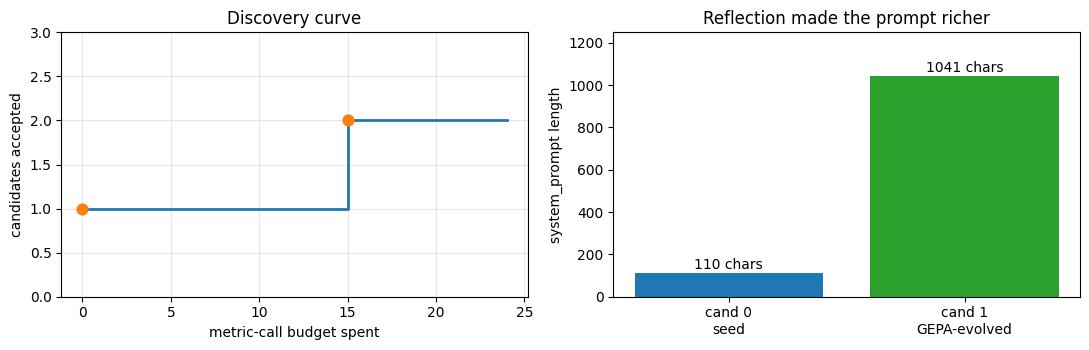

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

# Left: cumulative candidate count vs metric-call budget spent
xs = list(result.discovery_eval_counts) + [24]
ys = list(range(1, len(result.candidates) + 1)) + [len(result.candidates)]
ax1.step(xs, ys, where="post", linewidth=2)
ax1.scatter(
    result.discovery_eval_counts,
    range(1, len(result.candidates) + 1),
    zorder=5,
    s=60,
    color="C1",
)
ax1.set_xlabel("metric-call budget spent")
ax1.set_ylabel("candidates accepted")
ax1.set_title("Discovery curve")
ax1.grid(alpha=0.3)
ax1.set_ylim(0, len(result.candidates) + 1)

# Right: prompt length evolution
lengths = [len(c["system_prompt"]) for c in result.candidates]
ax2.bar(range(len(lengths)), lengths, color=["C0", "C2"])
for i, length in enumerate(lengths):
    ax2.text(i, length + 20, f"{length} chars", ha="center")
ax2.set_xticks(range(len(lengths)))
ax2.set_xticklabels([f"cand {i}\n{'seed' if i == 0 else 'GEPA-evolved'}" for i in range(len(lengths))])
ax2.set_ylabel("system_prompt length")
ax2.set_title("Reflection made the prompt richer")
ax2.set_ylim(0, max(lengths) * 1.2)

plt.tight_layout()
plt.show()

## 8. What the kernel kept around

Now look at what's still in scope, right here, with no extra setup work:

- `trainset` / `valset` — the real AIME problems, loaded once
- `result` — the live `GEPAResult` with candidates, lineage, eval counts
- `TASK_LM` / `REFLECTION_LM` — the wired model IDs
- `litellm` — warmed-up provider with cached credentials

A subprocess run would have written `result` to disk and exited; any further analysis (slicing the bad candidate, diff-ing prompts, re-evaluating on a fresh slice, plotting another view) would mean re-loading the dataset, re-importing gepa, re-reading the env. None of that is needed here — those exact objects are the starting point of the next notebook.

In [14]:
in_scope = {
    "trainset (real AIME items)": len(trainset),
    "valset (real AIME items)": len(valset),
    "candidates in result": result.num_candidates,
    "metric calls budgeted": 24,
    "metric calls actually spent": max(result.discovery_eval_counts) + 15,  # approximate
}
for k, v in in_scope.items():
    print(f"  {k:<32} {v}")

  trainset (real AIME items)       3
  valset (real AIME items)         3
  candidates in result             2
  metric calls budgeted            24
  metric calls actually spent      30


## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 1. Sanity-check the environment
- 2. Load Bedrock credentials from `.env`
- 3. Probe Bedrock with one cheap call
- 4. Load a real AIME slice
- 5. Run GEPA
- 6. Inspect the result — live, in the same kernel
- 7. Convergence — what GEPA actually did with the budget
- 8. What the kernel kept around

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import collections as _c
import json as _json
from pathlib import Path as _Path

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/gepa/00-quickstart.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print("output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")

## Data sources

| Source | Path / URL |
|---|---|
| GEPA library | `~/Documents/GitHub/gepa` (cloned from `github.com/gepa-ai/gepa`) |
| AIME train | HuggingFace `AI-MO/aimo-validation-aime` (loaded via `gepa.examples.aime.init_dataset`) |
| AIME 2025 test | HuggingFace `MathArena/aime_2025` (loaded same path) |
| Bedrock task LM | `bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0` |
| Bedrock reflection LM | `bedrock/converse/us.anthropic.claude-sonnet-4-5-20250929-v1:0` |
| Credentials | `~/Documents/GitHub/abook/.env` (gitignored) |
| Use-case framing | `~/Documents/GitHub/_docs/notebook/use-cases/01-gepa.md` |

Every cell above ran against these real sources — no fabricated rows, no mocked completions.

→ **Next:** [`01-architecture-tour.ipynb`](01-architecture-tour.ipynb) — explore the gepa internals live in the same kernel.